Train Neural Networks to estimate Likelihood Ratios
===

In this notebook we will setup the neural networks that train unbiased and low-variance density ratios to be then used for neural simulation-based inference. 

In [1]:
import os, sys, pathlib, importlib
sys.path.append('../')

import os
import sys
import argparse
import warnings
import logging
import numpy as np
import yaml
import mplhep as hep

import nsbi_common_utils

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

hep.style.use(hep.style.ATLAS)

/home/jsandesara_umass_edu/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:10: FutureWarning: ``set_style`` is deprecated: Naming convention is changing to match mpl. Use ``mplhep.style.use()``.
  hep.set_style("ATLAS")


In [2]:
def load_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

In [3]:
# Load the workflow parameters
config_workflow = load_config("config.pipeline.yaml")["neural_likelihood_ratio_estimation"]

# Load the fit configuration
nsbi_fit_config_path = config_workflow["nsbi_fit_config"]
fit_config_nsbi = nsbi_common_utils.configuration.ConfigManager(file_path_string=nsbi_fit_config_path)

In [4]:
# Load the training features defined in fit configuration file -- this can also be passed separately if just using training APIs
features, features_scaling = fit_config_nsbi.get_training_features()

Statistical Model
-

The statistical model for the analysis can be written as: 

$$p(x|\mu, \alpha) = \frac{1}{\nu(\mu, \alpha)} \sum_c f_c(\mu) \cdot \nu_c(\alpha) \cdot p_c\left(x|\alpha\right)$$

where $c$ stands for the various physics channels that contribute to the final state $x$, **$\mu$ is the signal-strength parameter and $\alpha$ is the vector of nuisance parameters associated with the various systematic uncertainties in the model**. Note that we are assuming that the parameter $\mu$-dependence is known analytically, given by $f(\mu)$ and that we have simulation models for each of the channels $p_c(x)$. 

Setting up the test
-

The objective is to build the test statistic for composite hypothesis testing:

$$t_\mu = -2 \cdot \frac{\text{Pois}(\mathcal{N}_\text{evts}|\mu, \hat{\hat{\alpha}})}{\text{Pois}(\mathcal{N}_\text{evts}|\hat{\mu}, \hat{\alpha})} -2 \cdot \sum_i^{\mathcal{N}_\text{evts}} w_i \times \log \frac{p(x_i|\mu, \hat{\hat{\alpha}})}{p(x_i|\hat{\mu}, \hat{\alpha})} + \sum_m^{N_\text{systs}} \alpha_m^2$$

A direct approach would then be to model the probability density $p(x|\mu, \alpha)$. This can be done using generative models like Normalizing Flows. 

In the presence of high-dimensional inputs, including discrete inputs like the number of jets, this is a more difficult task than training probability density *ratios*. We rewrite the test statistic to turn this into a density ratio estimation task:

$$t_\mu = -2 \cdot \frac{\text{Pois}(\mathcal{N}_\text{evts}|\mu, \hat{\hat{\alpha}})}{\text{Pois}(\mathcal{N}_\text{evts}|\hat{\mu}, \hat{\alpha})} -2 \cdot \sum_i^{\mathcal{N}_\text{evts}} w_i \times \log \frac{p(x_i|\mu, \hat{\hat{\alpha}})/p_{ref}(x)}{p(x_i|\hat{\mu}, \hat{\alpha})/p_{ref}(x)} + \sum_m^{N_\text{systs}} \alpha_m^2$$


Then using the analytical statistical model:

$$\frac{p(x|\mu, \alpha)}{p_{ref}(x)} = \frac{1}{\nu(\mu, \alpha)} \sum_c f_c(\mu) \cdot \nu_c(\alpha) \cdot \frac{p_c\left(x|\alpha\right)}{p_{ref}(x)}$$

Further rewriting of the model, factorizing out the $\alpha$-dependence gives,

$$\frac{p(x|\mu, \alpha)}{p_{ref}(x)} = \frac{1}{\sum_c G_c(\alpha) \cdot f_c(\mu) \cdot \nu_c} \sum_c f_c(\mu) \cdot G_c(\alpha)\cdot \nu_c \cdot g_c(x|\alpha) \cdot \frac{p_c\left(x\right)}{p_{ref}(x)}$$

Factorized approach:
--

Instead of training NNs parameterized on $\mu$ and $\alpha$, we use analytical parameterizations to simplify the problem to training only parameter-independent density ratios.

Let's set this up for the toy $H\to \tau\tau$ model we are using. **Neglecting the nuisance parameter dependence ($G_c(\alpha) = g_c(x|\alpha) = 1$), the probability model can be written as** 

$$\sum_c f_c(\mu) \cdot \nu_c(\mu) \cdot \frac{p_c\left(x\right)}{p_{ref}(x)} = \mu \cdot \nu_{H \to \tau\tau}(\mu) \cdot  \frac{p_{H \to \tau\tau}\left(x\right)}{p_{ref}(x)} + \nu_{t\bar{t}}(\mu) \cdot  \frac{p_{t\bar{t}}\left(x\right)}{p_{ref}(x)} + \nu_{Z \to \tau\tau}(\mu) \cdot  \frac{p_{Z \to \tau\tau}\left(x\right)}{p_{ref}(x)}$$

In the NSBI approach presented in this tutorial, the density ratio estimation as a function of the various nuisance parameters is factorized from the nominal density ratio estimation, and will be done in the  `Systematic_Uncertainty_Estimation.ipynb` notebook.

In [5]:
branches_to_load = features + ['presel_score'] # Can be defined independently of config when using just the APIs
    
# datasets library helps with preparation of data, reads metadata from fit configuration file
datasets_helper = nsbi_common_utils.datasets.datasets(
    config_path=nsbi_fit_config_path,
    branches_to_load=branches_to_load
)

In [6]:
# Loading datasets from paths defined in fit config
dataset_incl_dict = datasets_helper.load_datasets_from_config(load_systematics=False)

In [7]:
# The loaded dataframe is a dictionary, with "Nominal" key referring to the nominal dataset
dataset_incl_nominal = dataset_incl_dict["Nominal"].copy()

# Get the signal region events to be used for SBI fit
dataset_SR_nominal = datasets_helper.filter_region_dataset(dataset_incl_nominal, region="SR")

Density ratio training
===

Now we train the NNs for $\frac{p_c}{p_{ref}}(x)$ density ratios to build the full model. Our choice of reference hypothesis, motivated by the search-oriented mixture model described above, would be: 

$$p_{ref}(x) = p_{H \to \tau\tau}(x) = \frac{1}{\nu_{H \to \tau\tau}} \frac{d\sigma_{H \to \tau\tau}}{dx} $$

gives the POI $\mu-$parameterized model:

$$\sum_c \left[f_c(\mu) \cdot \frac{p_c\left(x\right)}{p_{ref}(x)} \right]= \mu + \frac{p_{t\bar{t}}\left(x\right)}{p_{H \to \tau\tau}(x)} + \frac{p_{Z \to \tau\tau}\left(x\right)}{p_{H \to \tau\tau}(x)}$$

But this has shown to cause numerical issues, since the ratio corresponding to the $\mu$-scaling signal term is exactly 1. In the absence of additional signal production mechansims, we instead use:

$$p_{ref}(x) = \frac{1}{\nu_{H \to \tau\tau} + \nu_{t\bar{t}}} \left[\frac{d\sigma_{H \to \tau\tau}}{dx} + \frac{d\sigma_{t\bar{t}}}{dx} \right]$$

giving a more numerically stable model:

$$\sum_c \left[f_c(\mu) \cdot \frac{p_c\left(x\right)}{p_{ref}(x)} \right]= \mu \cdot \frac{p_{H \to \tau\tau}\left(x\right)}{p_{ref}(x)} + \frac{p_{t\bar{t}}\left(x\right)}{p_{ref}(x)} + \frac{p_{Z \to \tau\tau}\left(x\right)}{p_{ref}(x)}$$

The task of estimating the $\mu$-parameterized density ratio is thus reduced to estimating three $\mu$-independent density ratios $\frac{p_{H \to \tau\tau}}{p_{ref}}(x)$, $\frac{p_{t\bar{t}}}{p_{ref}}(x)$ and $\frac{p_{Z \to \tau\tau}}{p_{ref}}(x)$ mixed together with an analytical parameterization (hence the name mixture model).

**NB**: This is the same as the *morphing-aware* approach of density ratio estimation in MadMiner

In [8]:
# Get the path where intermediate data from the workflow is saved
path_to_saved_data = config_workflow["saved_data_path"]
if not path_to_saved_data.endswith('/'):
    path_to_saved_data += '/'

print(path_to_saved_data)

saved_datasets/


In [9]:
training_output_dir_name = config_workflow["output_training_dir"]
training_output_path = os.path.join(path_to_saved_data, training_output_dir_name)
if not training_output_path.endswith('/'):
    training_output_path += '/'

print(training_output_path)

saved_datasets/output_training_nominal/


In [10]:
# Get the anchor/basis points used to build the full statistical model
basis_processes = fit_config_nsbi.get_basis_samples()
print(f"Basis processes: {basis_processes}")

# Basis points making up the reference hypothesis -- this can in principle be not restricted to basis points
ref_processes = fit_config_nsbi.get_reference_samples()
print(f"Reference processes: {ref_processes}")

Basis processes: ['ztautau', 'ttbar', 'htautau']
Reference processes: ['ttbar', 'htautau']


In [11]:
use_log_loss = config_workflow["use_log_loss"]
print(f"Use log-loss to converge to logLR: {use_log_loss}")


# Start afresh? Set delete_existing_models=True
delete_existing = config_workflow["delete_existing_models"]
print(f"Delete existing models?: {delete_existing}")

Use log-loss to converge to logLR: False
Delete existing models?: False


In [12]:
num_ensemble_members = config_workflow["num_ensemble_members_training"]
print(f"Number of ensemble members to train/load {num_ensemble_members}")

Number of ensemble members to train/load 25


In [13]:
NN_training_mix_model = {}

for process_type in basis_processes:

    NN_training_mix_model[process_type] = {}
    
    for ensemble_index in range(num_ensemble_members):
    
        # Prepare dataset to be passed to training
        dataset_mix_model = datasets_helper.prepare_basis_training_dataset(
            dataset_SR_nominal, 
            [process_type], 
            dataset_SR_nominal, 
            ref_processes, 
            denominatorisreferencehypothesis=False
        )
    
        output_name = f'{process_type}'
    
        path_to_figures = os.path.join(training_output_path, f'output_figures_{process_type}{ensemble_index}/')
        path_to_models = os.path.join(training_output_path, f'output_model_params_{process_type}{ensemble_index}/')
    
        # setup the training of density ratios using density_ratio_trainer API
        NN_training_mix_model[process_type][ensemble_index] = nsbi_common_utils.training.density_ratio_trainer(
                                                                                                dataset                 = dataset_mix_model,    # dataframe containing all the relevant features for training
                                                                                                weights                 = dataset_mix_model['weights_normed'].to_numpy(),
                                                                                                training_labels         = dataset_mix_model['train_labels'].to_numpy(),
                                                                                                features                = features,
                                                                                                features_scaling        = features_scaling,
                                                                                                sample_name             = [process_type, 'ref'],
                                                                                                output_name             = output_name,
                                                                                                path_to_figures         = path_to_figures,
                                                                                                path_to_models          = path_to_models,
                                                                                                use_log_loss            = use_log_loss,
                                                                                                delete_existing_models  = delete_existing
                                                                                            )
        
        del dataset_mix_model


Neural Network architecture
===

Here we will start with a multi-layer perceptron (simple feed-forward Neural Network with fully-connected layers). This can be supplemented with more complex architectures like transformers. 

After detailed tuning during the off-shell Higgs boson analysis effort, we found that a network with very wide layers ($\geq 1000$) and a depth of less than 10 works best - alongside batch size of a few hundreds and a gradually declining learning rate that starts with a value just large enough to not blow up.

Starting with the training and validation of the various density ratio:

$$\frac{p_{H\to\tau\tau}(x)}{p_\text{ref}(x)}, \frac{p_{t\bar{t}}(x)}{p_\text{ref}(x)}, \frac{p_{Z \to \tau\tau}(x)}{p_\text{ref}(x)}$$

In [14]:
# Flag that forces the retraining of density ratios
force_train = config_workflow["force_train"]
print(f"Force retraining despite existing models?: {force_train}")

Force retraining despite existing models?: False


In [15]:
# Get training hyperparameters
training_settings = config_workflow["training_settings"]
print(f"Common training settings: {training_settings}")

Common training settings: {'htautau': {'hidden_layers': 4, 'neurons': 1000, 'number_of_epochs': 100, 'batch_size': 1024, 'learning_rate': 0.0001, 'scalerType': 'MinMax', 'calibration': False, 'recalibrate_output': False, 'type_of_calibration': 'histogram', 'num_bins_cal': None, 'callback': True, 'callback_patience': 30, 'callback_factor': 0.01, 'validation_split': 0.1, 'holdout_split': 0.25, 'load_trained_models': True, 'verbose': 1, 'plot_scaled_features': False, 'num_workers': 4}, 'ttbar': {'hidden_layers': 4, 'neurons': 1000, 'number_of_epochs': 100, 'batch_size': 1024, 'learning_rate': 0.0001, 'scalerType': 'MinMax', 'calibration': False, 'recalibrate_output': False, 'type_of_calibration': 'histogram', 'num_bins_cal': None, 'callback': True, 'callback_patience': 30, 'callback_factor': 0.01, 'validation_split': 0.1, 'holdout_split': 0.25, 'load_trained_models': True, 'verbose': 1, 'plot_scaled_features': False, 'num_workers': 4}, 'ztautau': {'hidden_layers': 4, 'neurons': 1000, 'num

In [16]:
for process_type in basis_processes:
    for ensemble_index in range(num_ensemble_members):

        # Get training hyperparameters
        training_settings = config_workflow["training_settings"]
    
        if process_type not in training_settings:
            raise KeyError(f"Missing config for {process_type}")
            
        settings = training_settings[process_type].copy()
        
        settings["ensemble_index"] = ensemble_index
        settings["num_workers"] = 0
        print(f"Starting training/loading for {process_type}")
        NN_training_mix_model[process_type][ensemble_index].train(**settings)
        NN_training_mix_model[process_type][ensemble_index].test_normalization()

Starting training/loading for ztautau


2026-03-10 08:52:39 | INFO | Training Logs | Reading saved models from saved_datasets/output_training_nominal/output_model_params_ztautau0/
2026-03-10 08:52:47 | INFO | Training Logs | 


The sum of PDFs is 1.0084832877041543




Starting training/loading for ztautau


2026-03-10 08:52:49 | INFO | Training Logs | Reading saved models from saved_datasets/output_training_nominal/output_model_params_ztautau1/
2026-03-10 08:52:55 | INFO | Training Logs | 


The sum of PDFs is 0.9959927777765103




Starting training/loading for ztautau


...

2026-03-10 09:03:15 | INFO | Training Logs | Reading saved models from saved_datasets/output_training_nominal/output_model_params_htautau22/
2026-03-10 09:03:24 | INFO | Training Logs | 


The sum of PDFs is 1.0053772773190992




Starting training/loading for htautau


2026-03-10 09:03:27 | INFO | Training Logs | Reading saved models from saved_datasets/output_training_nominal/output_model_params_htautau23/
2026-03-10 09:03:36 | INFO | Training Logs | 


The sum of PDFs is 1.0062899581579647




Starting training/loading for htautau


2026-03-10 09:03:38 | INFO | Training Logs | Reading saved models from saved_datasets/output_training_nominal/output_model_params_htautau24/
2026-03-10 09:03:47 | INFO | Training Logs | 


The sum of PDFs is 1.0026387290096803




Check for overtraining by comparing the NN output distributions between training and holdout datasets. The holdout dataset is the subset of events not used during training.

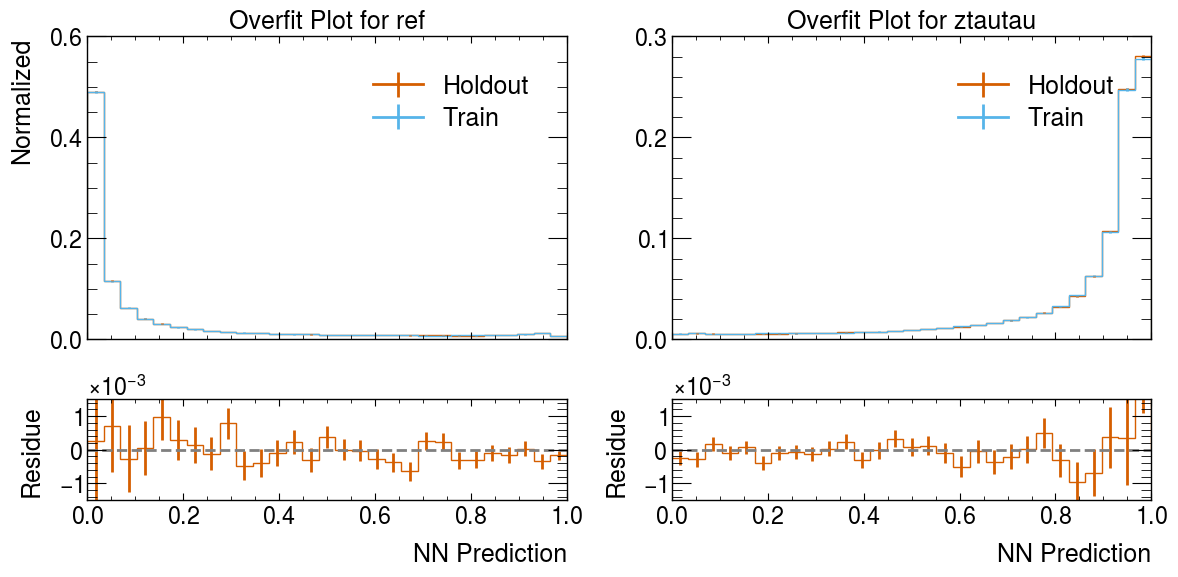

<Figure size 800x600 with 0 Axes>

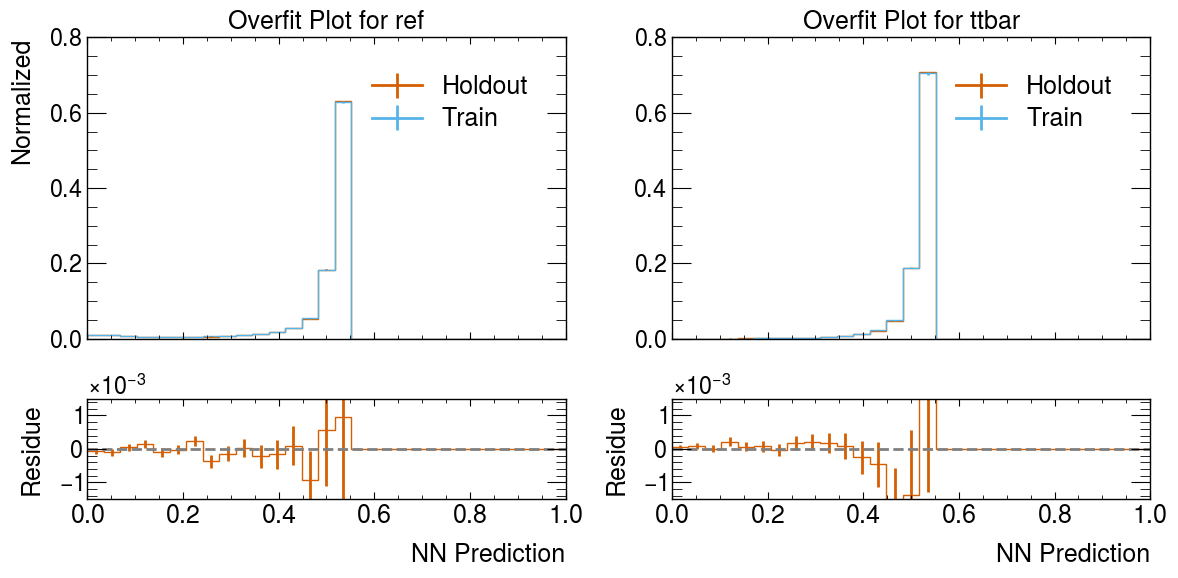

<Figure size 800x600 with 0 Axes>

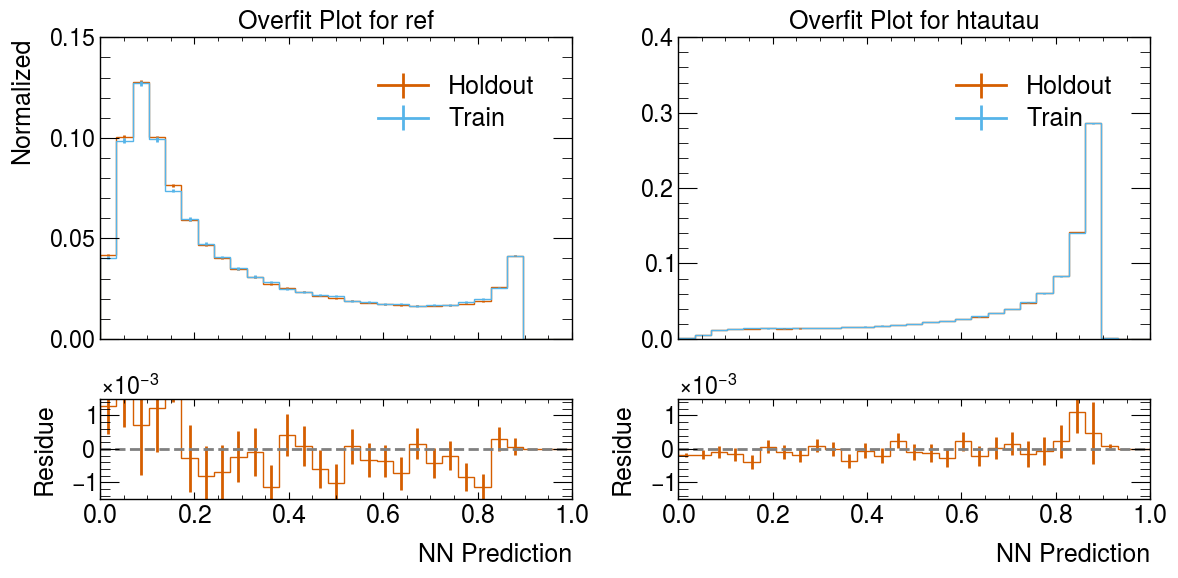

<Figure size 800x600 with 0 Axes>

In [17]:
ensemble_index_to_plot = 0

for process_type in basis_processes:
    NN_training_mix_model[process_type][ensemble_index_to_plot].make_overfit_plots()

Diagnostic Checks
===

While traditionally, a NN observable is judged on the basis of its accuracy - for NSBI we are interested in the quality of the density ratios more than the discrimination power. The latter comes from the perfect modelling of the multi-dimensional likelihood ratios.

To ensure correct modelling, we run two main checks on the training:

- **Calibration closure test**

  The NNs are trained using the binary cross-entropy loss, which under ideal conditions leads to the NN converging to the score function:

  $$\hat{s}_\text{pred} = \frac{p_\text{ref}(x)}{p_\text{ref}(x)+p_\text{c}(x)}$$

  that can be converted into the probability ratio we desire (likelihood ratio trick):

  $$\frac{p_\text{c}(x)}{p_\text{ref}(x)} = \frac{\hat{s}_\text{pred}(x)}{1-\hat{s}_\text{pred}(x)}$$

  For the NNs to be well-calibrated, we use the Monte Carlo samples to verify the equality:


  $$\left[\frac{p_c(x)}{p_c(x)+p_{ref}(x)}\right]_\text{NN} \sim \left[\frac{\mathcal{N}_c^{I(x|\hat{s}_\text{pred})}}{\mathcal{N}_c^{I(x|\hat{s}_\text{pred})}+\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}}\right]_\text{MC}$$

  where we bin the events from $p_c$ and $p_\text{ref}$ MC samples, denoted by $\mathcal{N}_c^{I(x|\hat{s}_\text{pred})}$ and $\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}$ respectively where $I(x|\hat{s}_\text{pred})$ returns the index of the $\hat{s}_\text{pred}$ bin in which an event $x$ falls.
 


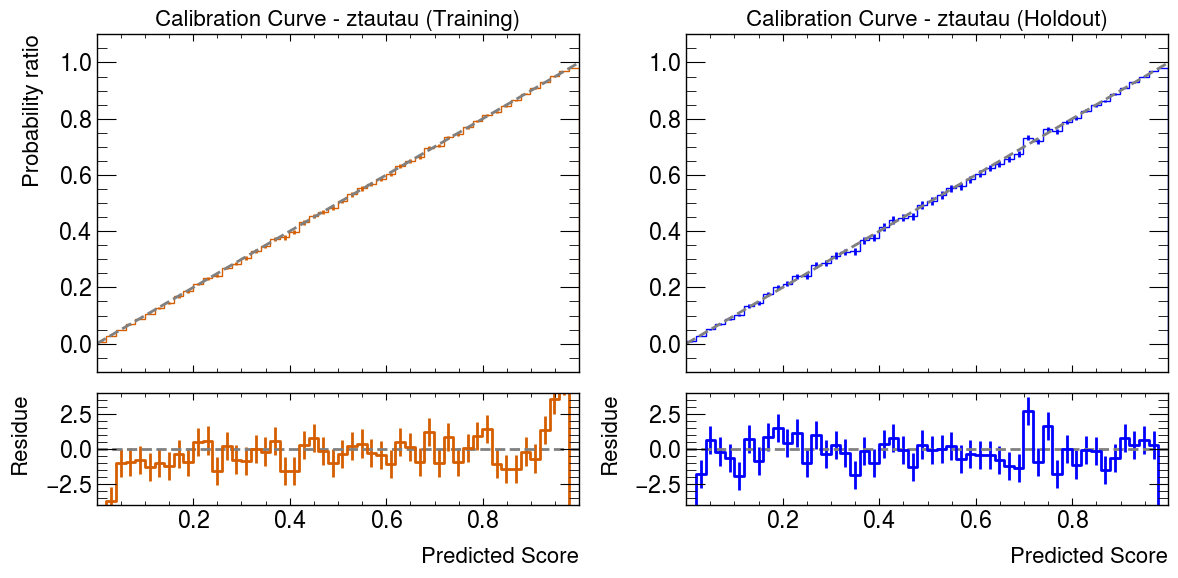

<Figure size 800x600 with 0 Axes>

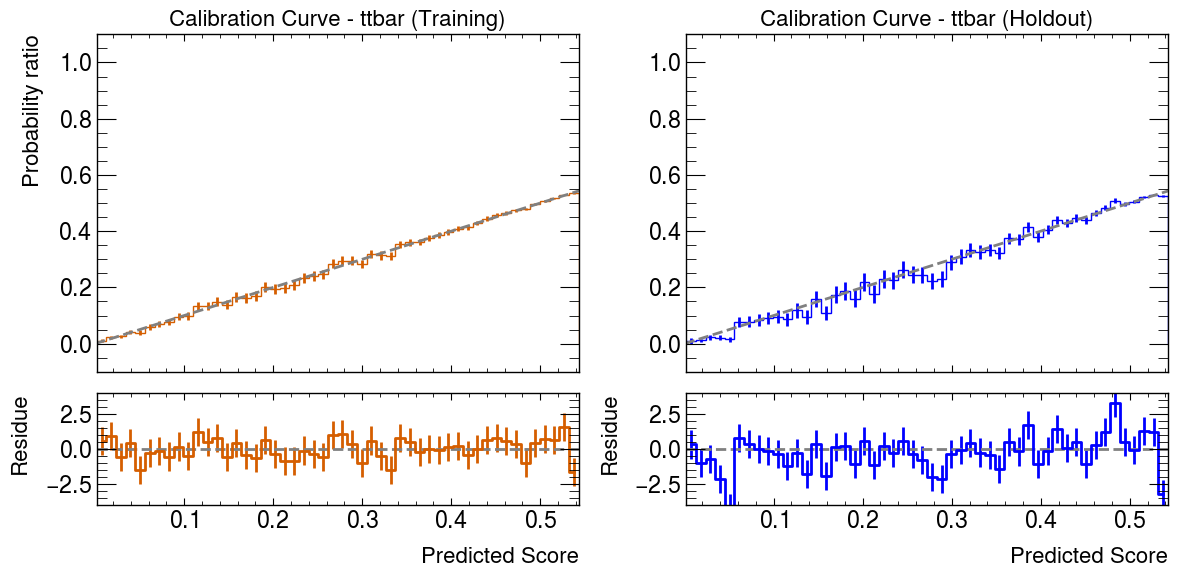

<Figure size 800x600 with 0 Axes>

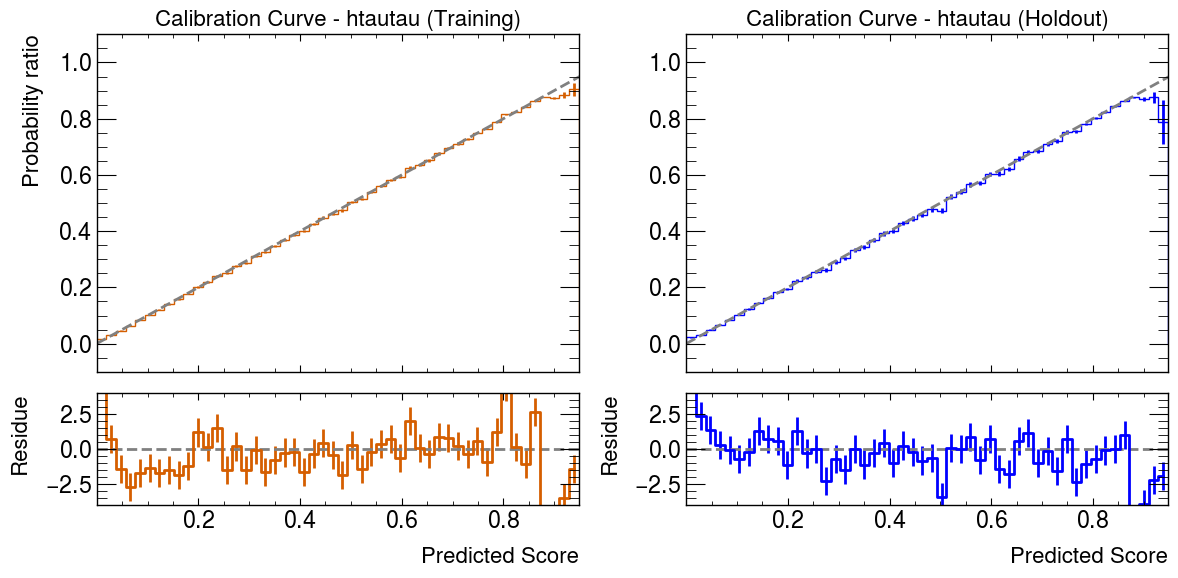

<Figure size 800x600 with 0 Axes>

In [18]:
ensemble_index_to_plot = 0
num_bins_cal = 50

for process_type in basis_processes:
    NN_training_mix_model[process_type][ensemble_index_to_plot].make_calib_plots(nbins=num_bins_cal, observable='score')

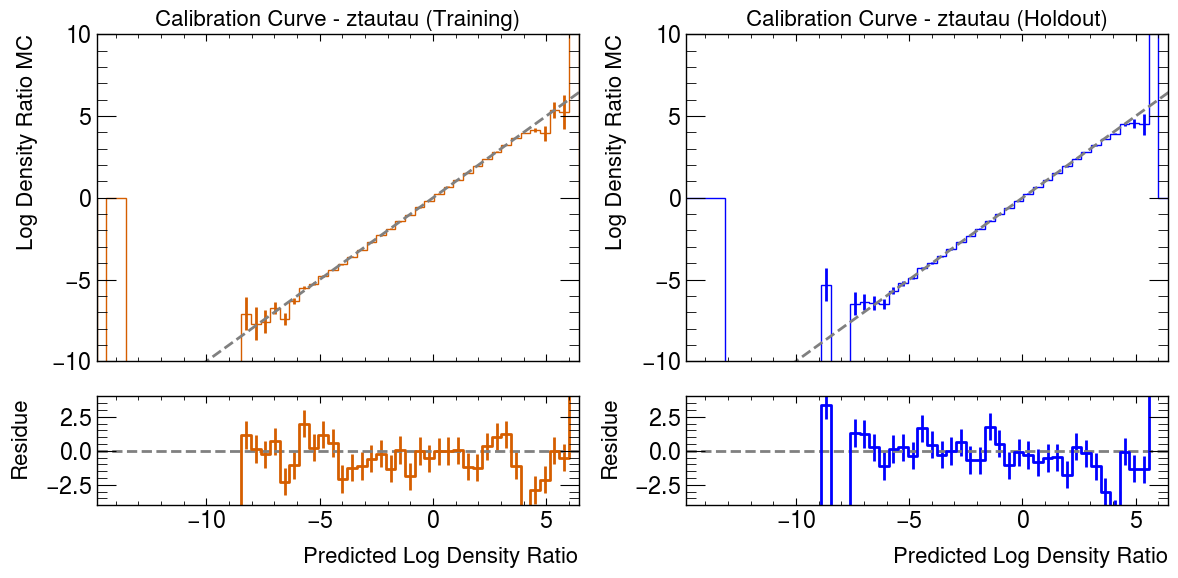

<Figure size 800x600 with 0 Axes>

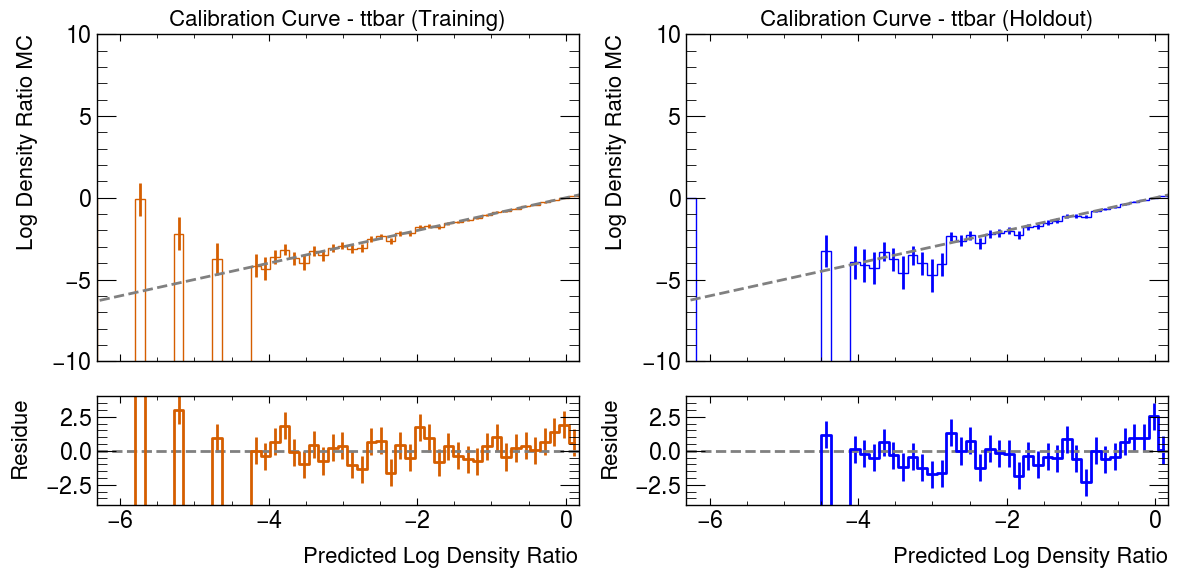

<Figure size 800x600 with 0 Axes>

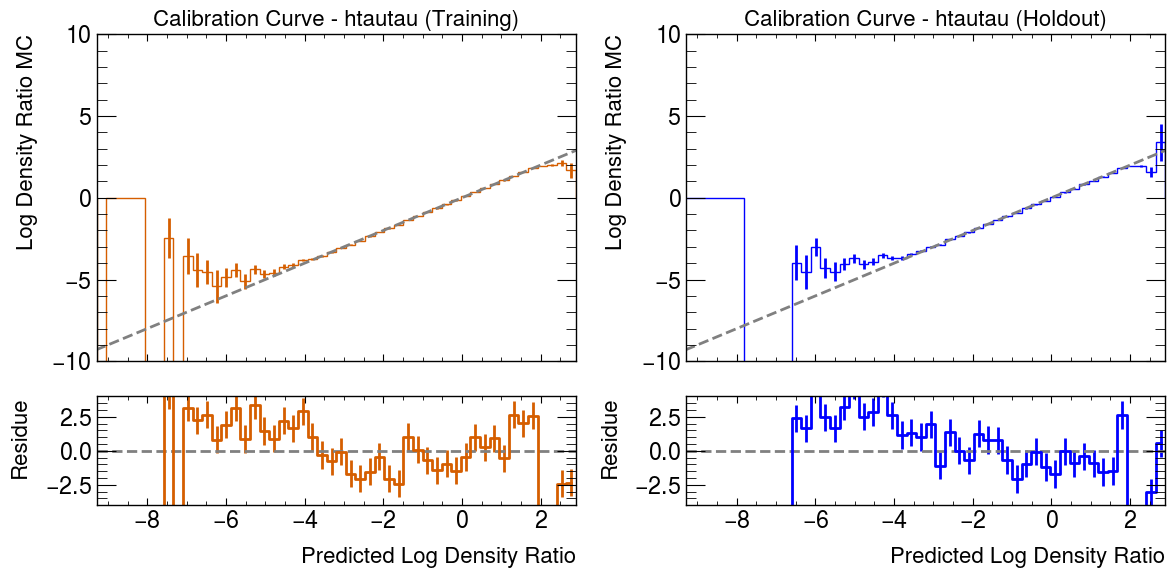

<Figure size 800x600 with 0 Axes>

In [19]:
ensemble_index_to_plot = 0
num_bins_cal = 50

for process_type in basis_processes:
    NN_training_mix_model[process_type][ensemble_index_to_plot].make_calib_plots(nbins=num_bins_cal, observable='llr')

## Density ratio reweighting closure tests
  
  Despite having a well-calibrated output and thus a robust probabilistic interpretation, the trained density ratios might not capture the full multi-dimensional event information $x$. In other words, the NNs might still be biased estimators of the optimal score function, as defined in the CARL paper (link).

  The next diagnostic involves verifying the following equality using 1D projections of $x$:

  $$\frac{p_c(x)}{p_{ref}(x)} \times p_{ref}(x) \sim p_c(x)$$

  We can do this one-by-one for all the observables used to model the density ratios, and also possibly the observables not used directly in the training but can still be well-estimated due to the NN learning the right physics.

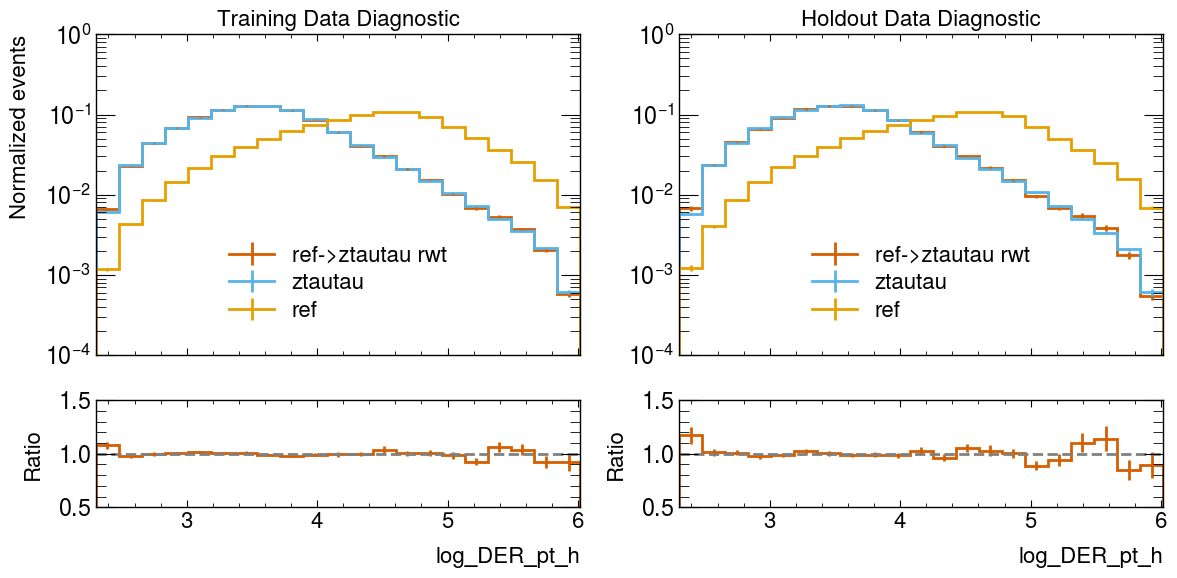

<Figure size 800x600 with 0 Axes>

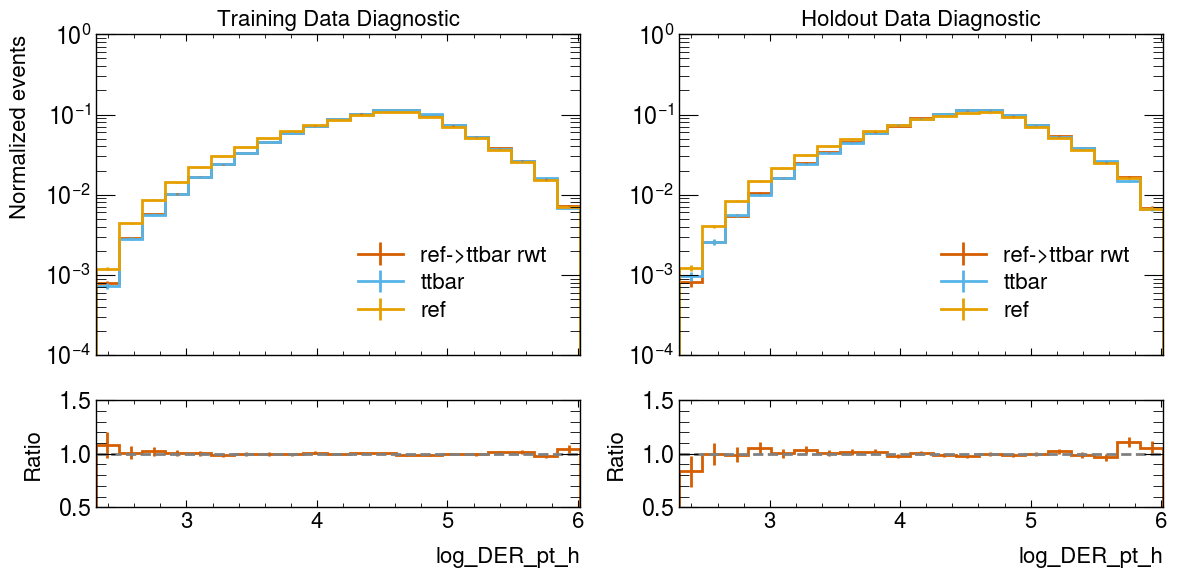

<Figure size 800x600 with 0 Axes>

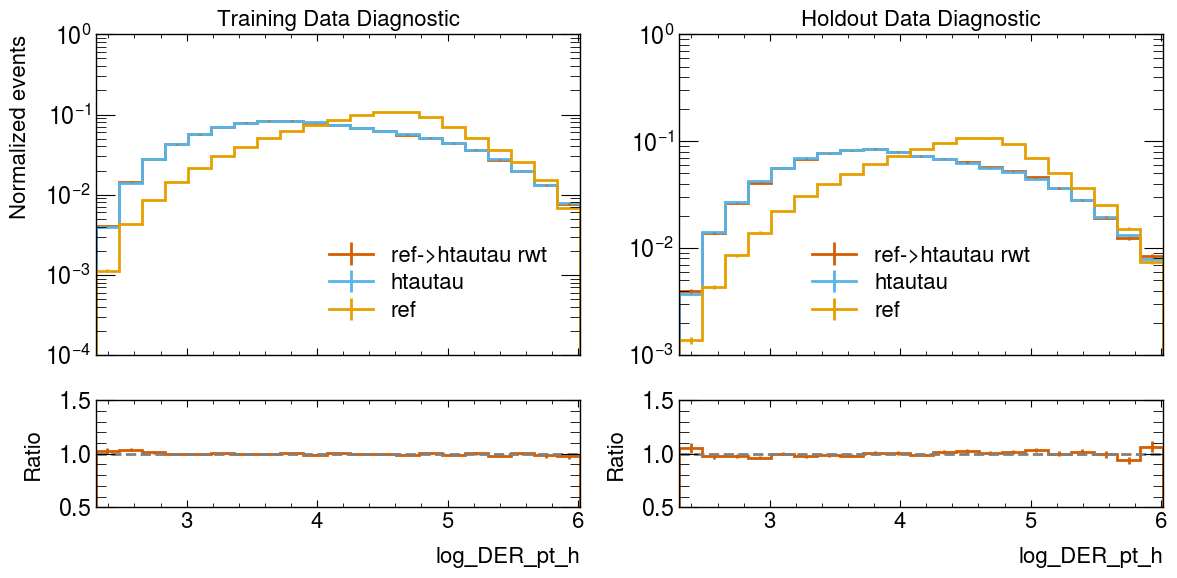

<Figure size 800x600 with 0 Axes>

In [21]:
variables_to_plot=['log_DER_pt_h'] # The 1D variable for reweighting closure
yscale_type='log'
num_bins_plotting=21

ensemble_index_to_plot = 0

for process_type in basis_processes:

    NN_training_mix_model[process_type][ensemble_index_to_plot].make_reweighted_plots(variables_to_plot, yscale_type, num_bins_plotting)


Systematic Uncertainty Modelling
===

So far we have left out the nuisance parameter piece of the parameterized density ratio decomposition shown before:

$$g_c(x|\alpha) = \frac{p_c(x|\alpha)}{p_c(x)}$$

which will be estimated in the `Systematic_Uncertainty_Estimation.ipynb` notebook.